In [6]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import util

##### DF Mac

In [4]:
data_path = "/Users/erik/Library/CloudStorage/OneDrive-Persönlich/Tübingen Studium/1. Semester/Data Literacy/Project/Data.csv"
df = pd.read_csv(data_path, sep=';', decimal=',')


##### DF Windows

In [ ]:
df = pd.read_csv('Data.csv', sep=';', decimal=',')

##### util load_data

In [7]:
df = util.load_data()
df

,jahr,geschlecht,altersklasse,disziplin,leistung,wind,name,geburtsjahr,verein,datum,ort
0,2017,W,Frauen,100 m,10.95,"+1,3",Gina Lueckenkemper,1996,LG Olympia Dortmund,05.08.,London/GBR
1,2017,W,Frauen,100 m,11.06,"+1,8",Rebekka Haase,1993,LV 90 Erzgebirge,25.05.,Zeulenroda
2,2017,W,Frauen,100 m,11.14,"-0,2",Lisa Mayer,1996,Sprintteam Wetzlar,27.08.,Berlin
3,2017,W,Frauen,100 m,11.24,"+0,3",Tatjana Pinto,1992,LC Paderborn,15.07.,Ninove/BEL
4,2017,W,Frauen,100 m,11.25,"+1,9",Sina Mayer,1995,LAZ Zweibruecken,11.06.,Regensburg
...,...,...,...,...,...,...,...,...,...,...,...
211554,2023,M,14,Speerwurf,40.64,NaN,Tizian Zoeger,2010,LAC Aschersleben,29.04.2023,Schoenebeck
211555,2023,M,14,Speerwurf,40.48,NaN,Phil Matthias,2009,SV Halle,07.05.2023,Halle (Saale)
211556,2023,M,14,Speerwurf,40.38,NaN,Laurin Steep,2009,MTV Dannenberg,16.09.2023,Fallersleben (Wolfsburg)
211557,2023,M,14,Speerwurf,40.36,NaN,Rico Lange,2009,TSV Chemie Premnitz,02.09.2023,Berlin-Lichterfelde


##### Average Time

In [ ]:
# Durchschnitt 100m
df['leistung_num'] = pd.to_numeric(
    df['leistung'].str.replace(',', '.', regex=False),
    errors='coerce'
)
durchschnitt_100m = df[df['disziplin'] == '100 m']['leistung_num'].mean()
print(
    f"{durchschnitt_100m:.2f} Sekunden"
)

# Durchschnitt 200m
df['leistung_num'] = pd.to_numeric(
    df['leistung'].str.replace(',', '.', regex=False),
    errors='coerce'
)
durchschnitt_200m = df[df['disziplin'] == '200 m']['leistung_num'].mean()
print(
    f"{durchschnitt_200m:.2f} Sekunden"
)

##### violin plot

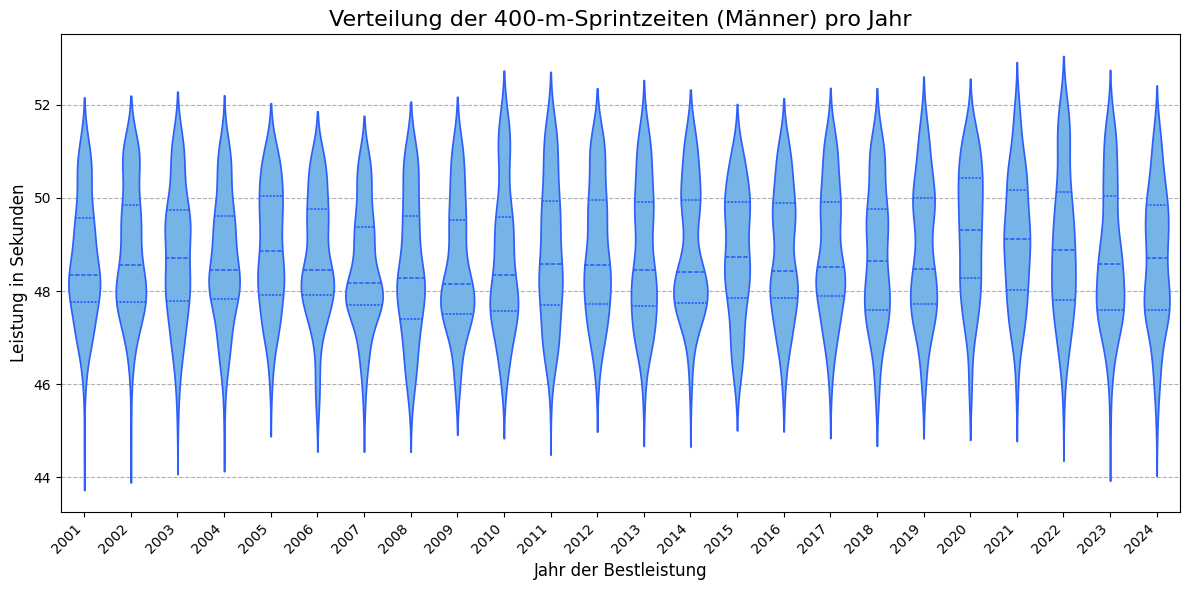

In [9]:
df_plot = df[
    (df['disziplin'] == '400 m') &
    (df['geschlecht'] == 'M')
].copy()

# Entferne alle Zeilen, bei denen die Leistung NaN ist (falls die Konvertierung fehlschlug)
df_plot.dropna(subset=['leistung'], inplace=True)


# 2. Violin Plot erstellen

# Setzen der Größe des Plots
plt.figure(figsize=(12, 6))

# Erstellung des Violin Plots mit seaborn
# x: Jahr, y: Zeit in Sekunden, data: gefilterter DataFrame
sns.violinplot(
    x='jahr',
    y='leistung',
    data=df_plot,
    inner='quartile',  # Fügt die Quartile (25%, 50%, 75%) als Linien hinzu
    color='#63B6FB',
    edgecolor='#2F5FFA',
    zorder=2
    # palette='viridis'  # Eine Farbskala
)

# 3. Titel und Achsenbeschriftungen hinzufügen
plt.title('Verteilung der 400-m-Sprintzeiten (Männer) pro Jahr', fontsize=16)
plt.xlabel('Jahr der Bestleistung', fontsize=12)
plt.ylabel('Leistung in Sekunden', fontsize=12)
plt.xticks(rotation=45, ha='right')

# Gitternetzlinien hinzufügen
plt.grid(axis='y', linestyle='--', zorder=1)

# Plot anzeigen
plt.tight_layout()  # Passt den Plot an, damit nichts abgeschnitten wird
plt.show()